# Working with Platforms

This notebook introduces the platform workflow in RobotBlockSet. Its purpose is to show how to create, configure, inspect, and operate platforms in a consistent way.


## What this notebook covers

The examples below demonstrate the typical steps for working with platforms, including imports, platform creation, basic state access, motion commands, and visualization or simulation-related checks.

Use this notebook as a practical starting point when you want to understand the platform API and adapt the workflow to your own platform model or test setup.


# Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

from robotblockset.tools import get_rbs_path
from robotblockset.platforms import MotionResultCodes, MotionResultStr
from robotblockset.mujoco.scene_pymujoco import mujoco_scene
from robotblockset.mujoco.platforms_pymujoco import tiagobase
from robotblockset.mujoco.robots_pymujoco import panda
from robotblockset.transformations import map_pose, rot_z

np.set_printoptions(formatter={"float": "{: 0.4f}".format})


## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.


Capture measured and commanded platform and robot states into global arrays for later plotting.

In [7]:
# Callback for Update
it = 0
def CaptureP_R(p):
    global it, trun,trun0, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtw, vtw, rxtw, rvtw, pxt, ptht, pvt, prxt, prvt, pmt, rTbt
    r = p.Robot
    if it == 0:
        tt = np.array(p.t)
        trun0 = time()
        trun = np.array(time() - trun0)

        if r is not None:
            qt = r._actual.q
            qdt = r._actual.qdot
            rqt = r._command.q
            rqdt = r._command.qdot
            xt = r._actual.x
            vt = r._actual.v
            rxt = r._command.x
            rvt = r._command.v
            mt = r._command.mode
            xtw = r.x
            vtw = r.GetVel(task_space="World", state="Actual")
            rxtw = r._command.rx
            rvtw = r.GetVel(task_space="World", state="Commanded")
            rTbt = r.GetBasePose(out="x")
        pxt = p._actual.x
        ptht = p.theta
        pvt = p._actual.v
        prxt = p._command.x
        prvt = p._command.v
        pmt = p._command.mode
    else:
        tt = np.vstack((tt, p.t))
        trun = np.vstack((trun, time() - trun0))
        if r is not None:
            qt = np.vstack((qt, r._actual.q))
            qdt = np.vstack((qdt, r._actual.qdot))
            rqt = np.vstack((rqt, r._command.q))
            rqdt = np.vstack((rqdt, r._command.qdot))
            xt = np.vstack((xt, r._actual.x))
            vt = np.vstack((vt, r._actual.v))
            rxt = np.vstack((rxt, r._command.x))
            rvt = np.vstack((rvt, r._command.v))
            mt = np.vstack((mt, r._command.mode))
            xtw = np.vstack((xtw, r.x))
            vtw = np.vstack((vtw, r.GetVel(task_space="World", state="Actual")))
            rxtw = np.vstack((rxtw, r._command.rx))
            rvtw = np.vstack((rvtw, r.GetVel(task_space="World", state="Commanded")))
            rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))
        pxt = np.vstack((pxt, p._actual.x))
        ptht = np.vstack((ptht, p.theta))
        pvt = np.vstack((pvt, p._actual.v))
        prxt = np.vstack((prxt, p._command.x))
        prvt = np.vstack((prvt, p._command.v))
        pmt = np.vstack((pmt, p._command.mode))

    it += 1

# Platform Objects

`platforms.py` defines the common interface for mobile platforms. It provides

- state accessors for wheel-joint and planar task-space variables,
- transformations between `World`, `Platform`, and `Object` coordinate systems,
- planar motion commands for differential-drive style bases,
- motion supervision and capture callbacks,
- optional attachment of a robot to the moving base.

This tutorial uses a MuJoCo-backed `tiagobase` platform object.


# Creation Of A Platform Object

The platform backend depends on the target system. In this tutorial we use the MuJoCo simulator and create a `tiagobase` object.


In [8]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/tiagobase_panda_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, synchronized=True, verbose=1)

base = tiagobase(scene=scene)


[RBS_INFO] [07:27:32] [tiagobase_PyMuJoCo]: Platform connected to MuJoCo


In [9]:
# from robotblockset.mujoco.platforms_mujoco import tiagobase
# base = tiagobase()

> Note: additional constructor arguments can be passed as `name=value` pairs, for example custom joint names, actuator names, or MuJoCo sensor names.


# Platform States

All platform states are updated using method

| Method | Description |
| --- | --- |
| `base.GetState()` | Update platform states from the backend. |

States are refreshed automatically during motion and when getters request a refresh. The update period is defined by `base.tsamp`.


## Platform Properties

The same information can be accessed through platform object properties. Properties without suffix return the current actual state, suffix `_ref` returns the commanded/reference state, and suffix `_err` returns the corresponding error.

| Property | Description |
| --- | --- |
| `base.Time` | Elapsed wall-clock time since initialization or `ResetTime()`. |
| `base.t` | Elapsed backend/platform time since the last reset. |
| `base.command` | Deep copy of the commanded state container. |
| `base.actual` | Deep copy of the measured state container. |
| `base.q` | Actual wheel-joint positions. |
| `base.qdot` | Actual wheel-joint velocities. |
| `base.trq` | Actual wheel-joint torques. |
| `base.x` | Actual platform pose in compact pose representation. |
| `base.p` | Actual platform position. |
| `base.Q` | Actual platform orientation as quaternion. |
| `base.R` | Actual platform orientation as rotation matrix. |
| `base.T` | Actual platform pose as homogeneous transform. |
| `base.theta` | Actual planar yaw angle. |
| `base.v` | Actual platform twist in world coordinates. |
| `base.pdot` | Actual planar linear velocity part. |
| `base.w` | Actual angular velocity part. |
| `base.FT` | Actual wrench. |
| `base.F` | Actual force part of the wrench. |
| `base.Trq` | Actual torque part of the wrench. |
| `base.q_ref`, `base.qdot_ref`, `base.x_ref`, `base.p_ref`, `base.Q_ref`, `base.R_ref`, `base.T_ref`, `base.theta_ref`, `base.v_ref`, `base.pdot_ref`, `base.w_ref`, `base.FT_ref`, `base.F_ref`, `base.Trq_ref` | Commanded/reference values. |
| `base.q_err`, `base.qdot_err`, `base.x_err`, `base.p_err`, `base.Q_err`, `base.R_err`, `base.T_err`, `base.theta_err`, `base.v_err`, `base.pdot_err`, `base.w_err` | Tracking errors between commanded and actual state. |


In [10]:
print("Pose   :", base.x)
print("Pos    :", base.p)
print("Theta  :", base.theta)
print("Vel 2d :", base.GetVel(out="2d"))


Pose   : [ 0.0000  0.0000  0.0995  1.0000 -0.0000  0.0001  0.0000]
Pos    : [ 0.0000  0.0000]
Theta  : 1.0996545718080653e-06
Vel 2d : [ 0.0004 -0.0000 -0.0000]


## Wheel Joint States

For a differential-drive base, the joint variables correspond to the platform wheel joints.

| Method | Description |
| --- | --- |
| `base.GetJointPos(state=...)` | Get wheel-joint positions. |
| `base.GetJointVel(state=...)` | Get wheel-joint velocities. |
| `base.GetJointTrq(state=...)` | Get wheel-joint torques. |

The `state` parameter accepts `"Actual"` or `"Commanded"`.


>⚠️**Note:** Joint states are only available in simulator targets and usually not on real platforms.

In [11]:
print(base.q_ref)
print(base.GetJointPos(state="Commanded"))
print(base.q_err)


[ 0.0000  0.0000]
[ 0.0000  0.0000]
[ 0.0000  0.0000]


## Planar Task-Space States

Platforms use three task coordinate systems:

| Space | Description |
| --- | --- |
| `"World"` | Global world frame. |
| `"Platform"` | Frame fixed to the mobile base. |
| `"Object"` | User-defined frame stored in `base.TObject`. |

The main state getters are

| Method | Description |
| --- | --- |
| `base.GetPose(...)` | Get platform pose. |
| `base.GetPos(...)` | Get platform position. |
| `base.GetOri(...)` | Get platform orientation. |
| `base.GetVel(...)` | Get platform velocity. |
| `base.GetFT(...)` | Get platform wrench. |

Important output forms for platforms are `"2d"` for planar pose/velocity/wrench, `"theta"` for orientation, and the standard spatial forms such as `"x"`, `"T"`, `"Q"`, and `"R"`.


In [12]:
print("World pose     :", base.GetPose(out="x", task_space="World"))
print("Platform pose 2d:", base.GetPose(out="2d", task_space="Platform"))
print("Object vel 2d  :", base.GetVel(out="2d", task_space="Object"))


World pose     : [ 0.0000  0.0000  0.0995  1.0000 -0.0000  0.0001  0.0000]
Platform pose 2d: [ 0.0000  0.0000  0.0000]
Object vel 2d  : [-0.0000 -0.0000 -0.0000]


## Object Frame And Coordinate Transforms

The object frame is a user-defined planar or spatial reference attached to the world. It is useful when platform goals are defined relative to a workstation, docking pose, or local map frame.

| Method | Description |
| --- | --- |
| `base.SetObject(x)` | Set the object frame. |
| `base.GetObject(out="T", task_space=...)` | Get the object frame. |
| `base.PlatformToWorld(x, typ=None)` | Map a quantity from platform coordinates to world coordinates. |
| `base.WorldToPlatform(x, typ=None)` | Map a quantity from world coordinates to platform coordinates. |
| `base.ObjectToWorld(x, typ=None)` | Map a quantity from object coordinates to world coordinates. |
| `base.WorldToObject(x, typ=None)` | Map a quantity from world coordinates to object coordinates. |

These transformation methods support poses, positions, orientations, twists, wrenches, Jacobians, 2D points, and scalar planar angles.


In [13]:
T_obj = map_pose(p=[1.0, 0.5, 0.0], Q=rot_z(np.pi / 4), out="T")
base.SetObject(T_obj)

print(base.GetObject(out="T"))
print(base.ObjectToWorld([0.2, 0.0]))
print(base.WorldToPlatform([1.0, 0.5]))


[[ 0.7071 -0.7071 -0.0000  1.0000]
 [ 0.7071  0.7071  0.0000  0.5000]
 [ 0.0000 -0.0000  1.0000  0.0000]
 [ 0.0000  0.0000  0.0000  1.0000]]
[ 1.1414  0.6414]
[ 1.0000  0.5000]


# Platform Motion

`platforms.py` provides low-level planar velocity commands and higher-level motion primitives built on top of them.


## Low-Level Velocity Command

| Method | Description |
| --- | --- |
| `base.Set_vel([v_forward, w_yaw], wait=None)` | Send a planar velocity command in the platform frame. |

The input is `[linear_velocity, angular_velocity]`. The backend converts this command to wheel velocities.


In [14]:
base.Set_vel([2, 0.0])
base.Wait(1)
base.Stop()

## High-Level Planar Motion Methods

The high-level planar motion commands in `platforms.py` share the same idea as robot high-level motion: you specify a target, timing or controller gains, and optional execution settings, while the method handles the repeated low-level velocity updates.

`PForward(d, ...)` and `PTurn(ang, ...)` are simple open-loop commands: they generate a scalar trajectory over time and apply forward or turning velocity for the specified duration. They are open-loop motion commands and they set the corresponding velocities just for a defined time `t`, i.e., they do not assure that the final desired value is reached.

| Method | Description |
| --- | --- |
| `base.PForward(d, t=1, traj=None, asynchronous=False)` | Drive forward for distance `d`. |
| `base.PTurn(ang, t=1, traj=None, asynchronous=False)` | Rotate in place by `ang`. |

`traj` is the trajectory profile used to ramp the open-loop scalar motion, e.g. polynomial or trapezoidal profile. 


`CMoveToOri(theta, ...)` and `CMoveToLocation(rp, ...)` are closed-loop planar commands: they repeatedly recompute the control input from the current pose until the orientation or position error becomes small enough.

| Method | Description |
| --- | --- |
| `base.CMoveToOri(rtheta, ...)` | Rotate to an absolute planar orientation `rtheta`. |
| `base.CMoveToLocation(rp, rtheta=None, ...)` | Move to a target planar location `rp`, optionally with final orientation `rtheta`. |

`CMoveToLocation` accepts platform-specific options such as `allow_backward`, `approach_dist`, `final_orientation_correction`, and `reach_check_fn`.


Here is the list of all arguments for both commands


| Argument | Description |
| -------- | ----------- |
| `rtheta` | Desired final planar orientation angle for `CMoveToOri` or optional final orientation for `CMoveToLocation`. |
| `rp` | Target planar position for `CMoveToLocation`. It can be a 2D point or a 3D planar pose `[x, y, theta]`. |
| `task_space` | Frame in which the target is interpreted. Supported planar frames are typically `"World"`, `"Object"`, and `"Platform"`. |
| `wait` | Maximum control time / waiting time allowed for the closed-loop command. If omitted, defaults from the platform are used. |
| `vel_fac` | Velocity scaling factor relative to the platform speed limits. |
| `ori_err` | Orientation tolerance used to decide that the desired heading has been reached. |
| `pos_err` | Position tolerance used by `CMoveToLocation` to decide that the target position has been reached. |
| `k_rot` | Proportional gain for orientation-only control in `CMoveToOri`. |
| `k_dist` | Distance-control gain used in `CMoveToLocation` for forward motion toward the target. |
| `k_dir` | Direction / heading-control gain used in `CMoveToLocation`. |
| `min_dist` | Distance threshold limiting how close the commanded target may be before special handling is used. |
| `approach_dist` | Distance from the goal at which the final approach/orientation behavior changes. |
| `final_orientation_correction` | If `True`, `CMoveToLocation` performs an additional final heading correction when needed. |
| `robot_as_a_sensor` | If `True`, the attached robot pose is used when checking the effective platform approach geometry. |
| `allow_backward` | If `True`, `CMoveToLocation` may choose a backward approach instead of always turning to drive forward. |
| `reach_check_fn` | Optional user callback for custom reach/termination logic during `CMoveToLocation`. |
| `asynchronous` | If `True`, the command is launched in a background thread and returns immediately; otherwise the notebook waits until the motion finishes. |
| `**kwargs` | Additional optional parameters forwarded to helper logic inside the controller. |

In short: the first argument defines **what planar target to reach**, while the remaining arguments define **how fast to move, in which frame to interpret the target, how to decide the target is reached, and whether the call blocks or runs in the background**.

Argument `asynchronous=True` does not change how the motion is generated; it only changes **how the command is launched**. In methods such as `JMove` and `CMove`, the public method starts a Python `Thread` and immediately returns that thread object, while the actual motion is still executed by the corresponding internal method (`_JMove`, `_CMove`, ...). With `asynchronous=False` the same internal method is called directly, so the notebook waits until the motion finishes.

To prevent two motions from running on the same robot at the same time, `platforms.py` uses a single semaphore created as `Semaphore(1)` (`self._semaphore`). Before starting motion, motion methods check whether the semaphore is already taken; if yes, they return the result code `ACTIVE_THREADS` and print messages such as `"... not executed due to active threads!"`. If the semaphore is free, the motion acquires it, executes the motion, and then `Stop()` resets the semaphore so the next command can start.

In practice this means that asynchronous motion is useful when you want your Python code to continue running while the robot is moving. The background thread owns the semaphore until the motion ends (or `Stop()` is called after an interrupted motion), so a second motion command issued in the meantime for the same robot will be rejected. However, we can issue a motion command for another robot and hence, using `asynchronous` motion it is a way to run multiple robot motions in parallel. 

> ℹ️ **Note:** If due to run-time error the motion is interupted and not finished correctly, RBS could report error like:
>
> `... Move not executed due to active threads!`
>
> then it is necessary to reset motion threads using command `Stop()`


Here a simple sequence of platform motion:

In [15]:
base.Restart()
base.SetCaptureCallback(CaptureP_R)
base.ResetTime()
it = 0
base.StartCapture()
print(MotionResultStr(base.PForward(1, t=4, traj="line")))
base.Wait(1)
print(MotionResultStr(base.PTurn(np.pi / 2, t=2)))
base.Wait(1)
print(MotionResultStr(base.CMoveToOri(0.0, wait=5)))
base.Wait(1)
print(MotionResultStr(base.CMoveToLocation([0.0, 0.0, 0.0], wait=18)))
base.Wait(1)
base.StartCapture()


Motion completed successfully
Motion completed successfully
Motion completed successfully
Motion completed successfully


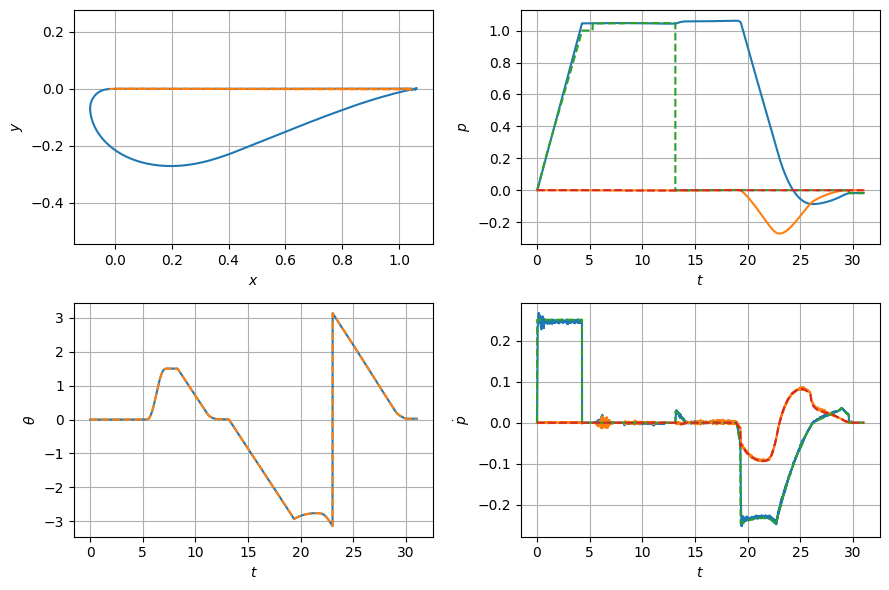

In [16]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 6))
ax[0, 0].plot(pxt[:,0],pxt[:,1], "-", label="$p$")
ax[0, 0].plot(prxt[:,0],prxt[:,1], "--", label="$p_r$")
ax[0, 0].grid()
ax[0, 0].axis("equal")
ax[0, 0].set_xlabel("$x$")
ax[0, 0].set_ylabel("$y$")

ax[1, 0].plot(tt, ptht, "-", label="$\\theta$")
ax[1, 0].plot(tt, ptht, "--", label="$\\theta_r$")
ax[1, 0].grid()
ax[1, 0].set_xlabel("$t$")
ax[1, 0].set_ylabel("$\\theta$")

ax[0, 1].plot(tt, pxt[:,:2], "-", label="$p$")
ax[0, 1].plot(tt, prxt[:,:2], "--", label="$p_r$")
ax[0, 1].grid()
ax[0, 1].set_xlabel("$t$")
ax[0, 1].set_ylabel("$p$")

ax[1, 1].plot(tt, pvt[:,:2], "-", label="$v$")
ax[1, 1].plot(tt, prvt[:,:2], "--", label="v_r$")
ax[1, 1].grid()
ax[1, 1].set_xlabel("$t$")
ax[1, 1].set_ylabel("$\\dot p$")

plt.tight_layout()


A target can also be expressed in the object frame or platform frame.


In [17]:
base.Restart()
base.SetObject(map_pose(p=[0.5, -0.5, 0.0], Q=rot_z(np.pi / 2), out="T"))
base.CMoveToLocation([0.3, 0.0, 0.0], task_space="Object", wait=16)
print("Position in object space:", base.GetPose(task_space="Object") )
print("Position in world  space:", base.GetPose(task_space="World")  )

Position in object space: [ 0.2818  0.0002 -0.0190]
Position in world  space: [ 0.4998 -0.2182  1.5518]


HEra are examples how the motion is influenced by argument `min_dist`

In [18]:
base.Restart()
base.SetCaptureCallback(CaptureP_R)
base.ResetTime()
it = 0
base.StartCapture()
base.CMoveToLocation([-1.0, 0.5])
base.CMoveToLocation([0.0, 0.0])
base.StartCapture()
pxt1 = pxt
ptht1 = ptht
tt1 = tt

In [19]:
base.Restart()
base.SetCaptureCallback(CaptureP_R)
base.ResetTime()
it = 0
base.StartCapture()
base.CMoveToLocation([-1.0, 0.5], rtheta=np.pi/2)
base.CMoveToLocation([0.0, 0.0], rtheta=0)
base.StartCapture()
pxt2 = pxt
ptht2 = ptht
tt2 = tt

In [20]:
base.Restart()
base.SetCaptureCallback(CaptureP_R)
base.ResetTime()
it = 0
base.StartCapture()
base.CMoveToLocation([-1.0, 0.5], rtheta=np.pi/2, min_dist=0.1)
base.CMoveToLocation([0.0, 0.0], rtheta=0, min_dist=0.1)
base.StartCapture()
pxt3 = pxt
ptht3 = ptht
tt3 = tt

In [21]:
base.Restart()
base.SetCaptureCallback(CaptureP_R)
base.ResetTime()
it = 0
base.StartCapture()
base.CMoveToLocation([-1.0, 0.5], rtheta=np.pi/2, min_dist=0)
base.CMoveToLocation([0.0, 0.0], rtheta=0, min_dist=0)
base.StartCapture()
pxt4 = pxt
ptht4 = ptht
tt4 = tt

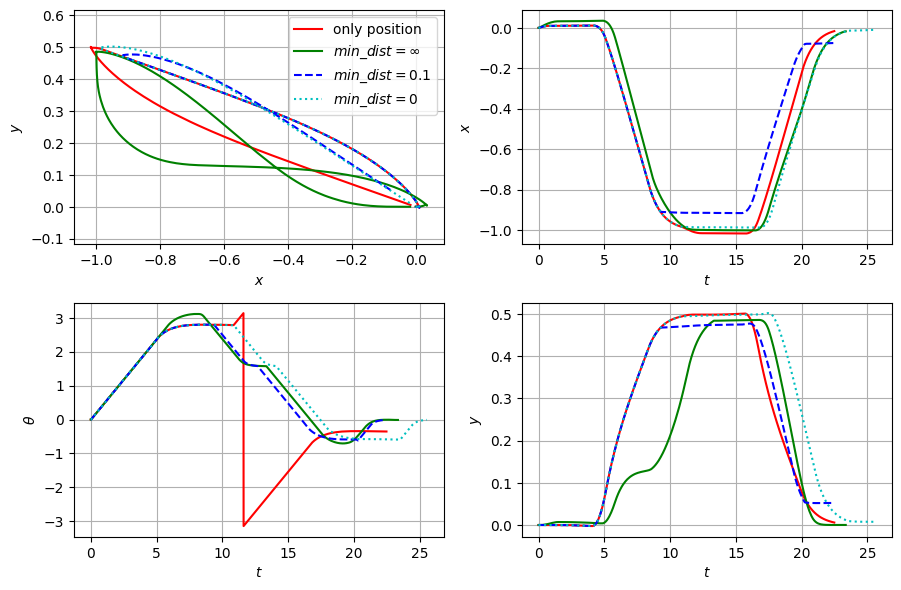

In [22]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 6))
ax[0, 0].plot(pxt1[:,0],pxt1[:,1], "r-", label="only position")
ax[0, 0].plot(pxt2[:,0],pxt2[:,1], "g-", label="$min\\_dist=\\infty$")
ax[0, 0].plot(pxt3[:,0],pxt3[:,1], "b--", label="$min\\_dist=0.1$")
ax[0, 0].plot(pxt4[:,0],pxt4[:,1], "c:", label="$min\\_dist=0$")
ax[0, 0].grid()
ax[0, 0].axis("equal")
ax[0, 0].set_xlabel("$x$")
ax[0, 0].set_ylabel("$y$")
ax[0, 0].legend()


ax[1, 0].plot(tt1[:,0],ptht1, "r-", label="only position")
ax[1, 0].plot(tt2[:,0],ptht2, "g-", label="$min\\_dist=\\infty$")
ax[1, 0].plot(tt3[:,0],ptht3, "b--", label="$min\\_dist=0.1$")
ax[1, 0].plot(tt4[:,0],ptht4, "c:", label="$min\\_dist=0$")
ax[1, 0].grid()
ax[1, 0].set_xlabel("$t$")
ax[1, 0].set_ylabel("$\\theta$")

ax[0, 1].plot(tt1[:,0],pxt1[:, 0], "r-", label="only position")
ax[0, 1].plot(tt2[:,0],pxt2[:, 0], "g-", label="$min\\_dist=\\infty$")
ax[0, 1].plot(tt3[:,0],pxt3[:, 0], "b--", label="$min\\_dist=0.1$")
ax[0, 1].plot(tt4[:,0],pxt4[:, 0], "c:", label="$min\\_dist=0$")
ax[0, 1].grid()
ax[0, 1].set_xlabel("$t$")
ax[0, 1].set_ylabel("$x$")

ax[1, 1].plot(tt1[:,0],pxt1[:, 1], "r-", label="only position")
ax[1, 1].plot(tt2[:,0],pxt2[:, 1], "g-", label="$min\\_dist=\\infty$")
ax[1, 1].plot(tt3[:,0],pxt3[:, 1], "b--", label="$min\\_dist=0.1$")
ax[1, 1].plot(tt4[:,0],pxt4[:, 1], "c:", label="$min\\_dist=0$")
ax[1, 1].grid()
ax[1, 1].set_xlabel("$t$")
ax[1, 1].set_ylabel("$y$")

plt.tight_layout()


## Motion Check Callback

Callbacks can interrupt a motion when a user-defined condition is met. For platforms this is useful for simple safety limits or stopping conditions based on position, heading, or external sensing.


In [23]:
base.Restart()
def stop_after_x_limit(base):
    if base.p[0] > 0.6:
        base.Stop()
        return MotionResultCodes.MOTION_ABORTED.value
    return MotionResultCodes.MOTION_SUCCESS.value

base.SetMotionCheckCallback(stop_after_x_limit)
base.EnableMotionCheck()
status = base.PForward(1.0, t=4)
base.DisableMotionCheck()
print(MotionResultStr(status))
print("Base position:", base.p)

[RBS_WARN] [1773902046.655042887] [tiagobase_PyMuJoCo]: Motion abborted
Motion was aborted
Base position: [ 0.6020  0.0002]


## Motion Capture

The update/capture utilities from `platforms.py` are the same mechanisms used by the motion loops internally. They can be used to log platform trajectories for later analysis.

| Method | Description |
| --- | --- |
| `base.Update()` | Refresh state and trigger capture callback when enabled. |
| `base.EnableUpdate()` / `base.DisableUpdate()` | Enable or disable state updates. |
| `base.GetUpdateStatus()` | Check whether updates are enabled. |
| `base.SetCaptureCallback(fun)` | Register a capture callback. |
| `base.StartCapture()` / `base.StopCapture()` | Enable or disable capture during updates. |
| `base.SetUserData(data)` / `base.GetUserData()` | Store custom data alongside the platform object. |


In [24]:
capture_t = []
capture_xy = []
capture_theta = []

def CapturePlatform(base):
    capture_t.append(base.t)
    capture_xy.append(base.p[:2].copy())
    capture_theta.append(base.theta)

base.Restart()
base.SetCaptureCallback(CapturePlatform)
base.ResetTime()
capture_t.clear()
capture_xy.clear()
capture_theta.clear()

base.StartCapture()
base.PForward(0.4, t=2)
base.PTurn(-np.pi / 3, t=2)
base.StopCapture()


Text(0.5, 1.0, 'Heading')

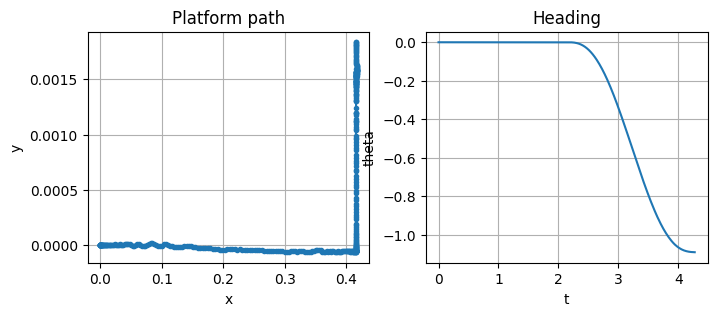

In [25]:
capture_xy = np.asarray(capture_xy)
fig, ax = plt.subplots(1, 2, num=1, figsize=(8, 3))
ax[0].plot(capture_xy[:, 0], capture_xy[:, 1], ".-")
ax[0].grid()
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Platform path")

ax[1].plot(capture_t, capture_theta)
ax[1].grid()
ax[1].set_xlabel("t")
ax[1].set_ylabel("theta")
ax[1].set_title("Heading")


# Platform Utilities

Some utility methods are especially relevant for mobile bases:

| Method | Description |
| --- | --- |
| `base.Kinmodel(q=None, out="x")` | Return the platform kinematic model and Jacobian. |
| `base.Jacobi()` | Return the platform Jacobian for the current state. |
| `base.Start()` / `base.Stop()` | Mark motion start/stop and reset command state. |
| `base.Wait(wait, dt=None)` | Wait while continuing update/callback processing. |
| `base.WaitUntilStopped(eps=...)` | Wait until wheel-joint velocity norm drops below `eps`. |
| `base.ResetTime()` | Reset timing counters. |
| `base.SetTsamp(tsamp)` | Change the sampling time used by motion/control loops. |
| `base.UseThreads(active)` | Enable or disable asynchronous thread usage. |
| `base.Check()` | Return backend/platform status messages. |
| `base.isReady()` / `base.isActive()` / `base.inMotion()` | Read platform readiness and motion state. |


In [26]:
x_model, J = base.Kinmodel(out="x")
print("Kinematic pose:", x_model)
print("Jacobian:\n", J)


Kinematic pose: [ 0.0000  0.0000  0.0000  1.0000  0.0000  0.0000  0.0000]
Jacobian:
 [[ 0.0493  0.0493]
 [ 0.0000  0.0000]
 [ 0.0000  0.0000]
 [ 0.0000  0.0000]
 [ 0.0000  0.0000]
 [-0.2436  0.2436]]


# Robot on Platform

A mobile platform can carry a robot. `platforms.py` therefore includes methods for storing the robot-base transform and keeping the attached robot base aligned with the platform motion.

| Method | Description |
| --- | --- |
| `base.AttachTo(robot)` | Attach a robot object to the platform. |
| `base.Detach()` | Detach the current robot. |
| `base.GetAttachedRobot()` | Return the attached robot object and its name. |
| `base.SetRobotBase(x)` | Define the robot base frame relative to the platform. |
| `base.GetRobotBase(out="T")` | Return the robot base transform relative to the platform. |
| `base.GetRobotBasePose(out=...)` | Return the robot base pose in the world frame. |

These methods are mainly used in mobile-manipulator setups. This tutorial keeps the example focused on the standalone platform, so no robot is attached here. For robots on platform see **tutorial_mobile_robots**.


# Default Parameters

Fallback parameters are stored in `base._default`. For platforms the most relevant ones are

| Parameter | Description |
| --- | --- |
| `State` | Default getter state, typically `"Actual"` or `"Commanded"`. |
| `TaskSpace` | Default frame for pose/velocity/wrench getters: `"World"`, `"Platform"`, or `"Object"`. |
| `TaskPoseForm` | Default pose output form. In `platforms.py` this is `"2d"`. |
| `TaskOriForm` | Default orientation output form. In `platforms.py` this is `"Theta"`. |
| `TaskVelForm` | Default velocity output form. |
| `TaskFTForm` | Default wrench output form. |
| `VelFac` | Global velocity scaling factor used by high-level motions. |
| `PosErr`, `OriErr` | Position and orientation tolerances for stopping. |
| `ApproachDist` | Distance threshold used by `CMoveToLocation` when shaping the approach. |
| `Krot`, `Kdist`, `Kdir` | Control gains for planar orientation and location motion. |
| `Traj` | Default trajectory type for `PForward` and `PTurn`. |
| `Wait` | Default control-loop horizon or wait time. |
| `UpdateTime` | Background update interval hint. |


In [27]:
for attr in dir(base._default):
    if not attr.startswith("_"):
        x = eval(f"base._default.{attr}")
        print(f"{attr} = {x}")


ApproachDist = 0.5
CheckObstacles = True
Kdir = 20
Kdist = 4
Krot = 10
LaserAngleRange = 0.7853981633974483
ObstacleMaxDist = 1
ObstacleMinDist = 0.4
ObstaclesForPlatform = True
OriErr = 0.01
PosErr = 0.01
Refresh = True
State = Actual
TaskFTForm = Wrench
TaskOriForm = Theta
TaskPoseForm = 2d
TaskSpace = World
TaskVelForm = Twist
Traj = poly
UpdateTime = 1.0
VelFac = 0.25
Wait = 0.1
